In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

In [2]:
print(os.getcwd())

C:\Users\user\Downloads


In [3]:
your_cab = pd.read_csv("D:\Projects\Project-Cab_cancellation_prediction\YourCabs_training.csv\YourCabs_training.csv")

In [4]:
your_cab

,id,user_id,vehicle_model_id,package_id,travel_type_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,to_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation,Cost_of_error
0,132512,22177,28,NaN,2,83.0,448.0,NaN,NaN,1/1/2013 2:00,NaN,0,0,1/1/2013 1:39,12.924150,77.672290,12.927320,77.635750,0,1.0
1,132513,21413,12,NaN,2,1010.0,540.0,NaN,NaN,1/1/2013 9:00,NaN,0,0,1/1/2013 2:25,12.966910,77.749350,12.927680,77.626640,0,1.0
2,132514,22178,12,NaN,2,1301.0,1034.0,NaN,NaN,1/1/2013 3:30,NaN,0,0,1/1/2013 3:08,12.937222,77.626915,13.047926,77.597766,0,1.0
3,132515,13034,12,NaN,2,768.0,398.0,NaN,NaN,1/1/2013 5:45,NaN,0,0,1/1/2013 4:39,12.989990,77.553320,12.971430,77.639140,0,1.0
4,132517,22180,12,NaN,2,1365.0,849.0,NaN,NaN,1/1/2013 9:00,NaN,0,0,1/1/2013 7:53,12.845653,77.677925,12.954340,77.600720,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43426,185937,14364,12,NaN,2,1147.0,452.0,15.0,NaN,11/24/2013 18:00,41602.82020,1,0,11/24/2013 14:25,13.030640,77.649100,12.952780,77.590880,0,1.0
43427,185938,48727,12,NaN,2,393.0,466.0,15.0,NaN,11/26/2013 1:00,41604.08037,1,0,11/24/2013 14:30,13.199560,77.706880,13.017436,77.644580,0,1.0
43428,185939,48729,12,1.0,3,974.0,NaN,15.0,NaN,11/24/2013 18:30,41602.97917,0,0,11/24/2013 14:35,13.075570,77.559040,NaN,NaN,0,1.0
43429,185940,30724,87,NaN,2,1263.0,542.0,15.0,NaN,11/24/2013 16:00,41602.69495,0,0,11/24/2013 14:43,12.968970,77.594560,12.938230,77.622890,0,1.0


In [5]:
your_cab.shape

(43431, 20)

In [6]:
your_cab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43431 entries, 0 to 43430
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   43431 non-null  int64  
 1   user_id              43431 non-null  int64  
 2   vehicle_model_id     43431 non-null  int64  
 3   package_id           7550 non-null   float64
 4   travel_type_id       43431 non-null  int64  
 5   from_area_id         43343 non-null  float64
 6   to_area_id           34293 non-null  float64
 7   from_city_id         16345 non-null  float64
 8   to_city_id           1588 non-null   float64
 9   from_date            43431 non-null  object 
 10  to_date              25541 non-null  float64
 11  online_booking       43431 non-null  int64  
 12  mobile_site_booking  43431 non-null  int64  
 13  booking_created      43431 non-null  object 
 14  from_lat             43338 non-null  float64
 15  from_long            43338 non-null 

In [7]:
your_cab.describe()

,id,user_id,vehicle_model_id,package_id,travel_type_id,from_area_id,to_area_id,from_city_id,to_city_id,to_date,online_booking,mobile_site_booking,from_lat,from_long,to_lat,to_long,Car_Cancellation,Cost_of_error
count,43431.000000,43431.000000,43431.00000,7550.000000,43431.000000,43343.000000,34293.000000,16345.000000,1588.000000,25541.000000,43431.000000,43431.000000,43338.000000,43338.000000,34293.000000,34293.000000,43431.000000,43431.000000
mean,159206.473556,30739.198153,25.71723,2.030066,2.137252,714.544494,669.490917,14.915081,68.537783,41507.974840,0.351592,0.043241,12.982461,77.636255,13.026648,77.640595,0.072114,8.000509
std,15442.386279,10996.476709,26.79825,1.461756,0.437712,419.883553,400.638225,1.165306,49.880732,305.144945,0.477473,0.203402,0.085933,0.059391,0.113487,0.064045,0.258680,25.350698
min,132512.000000,16.000000,1.00000,1.000000,1.000000,2.000000,2.000000,1.000000,4.000000,25569.020830,0.000000,0.000000,12.776630,77.386930,12.776630,77.386930,0.000000,0.150000
25%,145778.000000,24614.000000,12.00000,1.000000,2.000000,393.000000,393.000000,15.000000,32.000000,41480.521110,0.000000,0.000000,12.926450,77.593661,12.951850,77.582030,0.000000,1.000000
50%,159248.000000,31627.000000,12.00000,2.000000,2.000000,590.000000,541.000000,15.000000,49.000000,41517.761550,0.000000,0.000000,12.968887,77.635750,12.982750,77.645030,0.000000,1.000000
75%,172578.500000,39167.000000,24.00000,2.000000,2.000000,1089.000000,1054.000000,15.000000,108.000000,41558.914630,1.000000,0.000000,13.007750,77.688900,13.199560,77.706880,0.000000,1.000000
max,185941.000000,48730.000000,91.00000,7.000000,3.000000,1403.000000,1403.000000,31.000000,203.000000,41678.275680,1.000000,1.000000,13.366072,77.786420,13.366072,77.786420,1.000000,100.000000


In [8]:
your_cab.isnull().sum()

id                         0
user_id                    0
vehicle_model_id           0
package_id             35881
travel_type_id             0
from_area_id              88
to_area_id              9138
from_city_id           27086
to_city_id             41843
from_date                  0
to_date                17890
online_booking             0
mobile_site_booking        0
booking_created            0
from_lat                  93
from_long                 93
to_lat                  9138
to_long                 9138
Car_Cancellation           0
Cost_of_error              0
dtype: int64

In [9]:
your_cab.duplicated().sum()

np.int64(0)

In [10]:
your_cab = your_cab.drop(['from_city_id', 'to_city_id'], axis=1)

In [11]:
your_cab['package_id'] = your_cab['package_id'].fillna(0)

In [12]:
your_cab['from_area_id'] = your_cab['from_area_id'].fillna(
    your_cab['from_area_id'].mode()[0]
)

your_cab['to_area_id'] = your_cab['to_area_id'].fillna(0)

In [13]:
your_cab['from_lat'] = your_cab.groupby(
    'from_area_id'
)['from_lat'].transform(
    lambda x: x.fillna(x.mean())
)

your_cab['from_long'] = your_cab.groupby(
    'from_area_id'
)['from_long'].transform(
    lambda x: x.fillna(x.mean())
)

In [14]:
your_cab.isnull().sum().sort_values(ascending=False)

to_date                17890
to_long                 9138
to_lat                  9138
from_long                  5
from_lat                   5
id                         0
mobile_site_booking        0
Car_Cancellation           0
booking_created            0
online_booking             0
user_id                    0
from_date                  0
to_area_id                 0
from_area_id               0
travel_type_id             0
package_id                 0
vehicle_model_id           0
Cost_of_error              0
dtype: int64

In [15]:
print(your_cab['from_date'].dtype)
print(your_cab['booking_created'].dtype)
print(your_cab['to_date'].dtype)

object
object
float64


In [16]:
your_cab['from_date'] = pd.to_datetime(your_cab['from_date'])
your_cab['booking_created'] = pd.to_datetime(your_cab['booking_created'])
your_cab['to_date'] = pd.to_datetime(your_cab['to_date'], errors='coerce')

In [17]:
booking_count = your_cab.groupby('user_id').size()

your_cab['customer_booking_count'] = your_cab['user_id'].map(
    booking_count
)

In [18]:
your_cab['ride_hour'] = your_cab['from_date'].dt.hour
your_cab['ride_dayofweek'] = your_cab['from_date'].dt.dayofweek
your_cab['booking_hour'] = your_cab['booking_created'].dt.hour
your_cab['booking_dayofweek'] = your_cab['booking_created'].dt.dayofweek

your_cab['booking_advance_hours'] = (
    your_cab['from_date']
    - your_cab['booking_created']
).dt.total_seconds() / 3600

your_cab['is_same_day_booking'] = (
    your_cab['from_date'].dt.date
    ==
    your_cab['booking_created'].dt.date
).astype(int)

your_cab['trip_duration_hours'] = (
    your_cab['to_date']
    -
    your_cab['from_date']
).dt.total_seconds() / 3600

In [19]:
new_features = [
    'customer_booking_count',
    'ride_hour',
    'ride_dayofweek',
    'booking_hour',
    'booking_dayofweek',
    'booking_advance_hours',
    'is_same_day_booking',
    'trip_duration_hours'
]

your_cab[new_features].head()

,customer_booking_count,ride_hour,ride_dayofweek,booking_hour,booking_dayofweek,booking_advance_hours,is_same_day_booking,trip_duration_hours
0,1,2,1,1,1,0.350000,1,NaN
1,1,9,1,2,1,6.583333,1,NaN
2,1,3,1,3,1,0.366667,1,NaN
3,1,5,1,4,1,1.100000,1,NaN
4,1,9,1,7,1,1.116667,1,NaN


In [20]:
your_cab[
    [
        'booking_advance_hours',
        'trip_duration_hours',
        'customer_booking_count',
        'Cost_of_error'
    ]
].describe()

,booking_advance_hours,trip_duration_hours,customer_booking_count,Cost_of_error
count,43431.000000,25541.000000,43431.000000,43431.000000
mean,33.942075,-382666.144943,19.231263,8.000509
std,94.235821,1433.523824,60.483767,25.350698
min,-22.900000,-386621.750000,1.000000,0.150000
25%,2.883333,-383754.000000,1.000000,1.000000
50%,8.733333,-382765.000000,2.000000,1.000000
75%,18.316667,-381874.000000,7.000000,1.000000
max,1906.900000,-376953.750000,471.000000,100.000000


In [21]:
your_cab = your_cab.drop('trip_duration_hours', axis=1)

In [22]:
(your_cab['booking_advance_hours'] < 0).sum()

np.int64(42)

In [23]:
your_cab = your_cab[your_cab['booking_advance_hours'] >= 0].copy()

In [24]:
(your_cab['booking_advance_hours'] < 0).sum()

np.int64(0)

In [25]:
Q1 = your_cab['booking_advance_hours'].quantile(0.25)
Q3 = your_cab['booking_advance_hours'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = your_cab[
    (your_cab['booking_advance_hours'] < lower) |
    (your_cab['booking_advance_hours'] > upper)
]

print("Outliers:", len(outliers))
print("Upper Bound:", upper)

Outliers: 5592
Upper Bound: 41.483333333333334


In [26]:
def categorize_booking(hours):
    if hours <= 1:
        return 'Urgent'
    elif hours <= 5:
        return 'SameDay'
    elif hours <= 24:
        return 'Regular'
    else:
        return 'Advance'

your_cab['booking_nature'] = your_cab['booking_advance_hours'].apply(categorize_booking)

In [27]:
your_cab['booking_nature'].value_counts()

booking_nature
Regular    19643
SameDay    12789
Advance     8223
Urgent      2734
Name: count, dtype: int64

In [28]:
your_cab.groupby('booking_nature')['Car_Cancellation'].mean()

booking_nature
Advance    0.048036
Regular    0.056865
SameDay    0.123700
Urgent     0.013533
Name: Car_Cancellation, dtype: float64

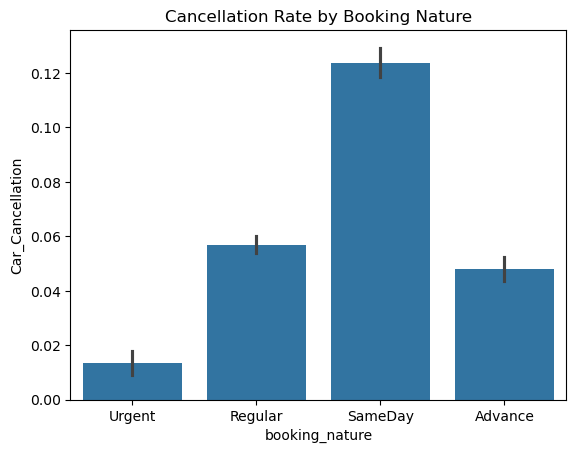

In [29]:
sns.barplot(
    x='booking_nature',
    y='Car_Cancellation',
    data=your_cab
)

plt.title('Cancellation Rate by Booking Nature')
plt.show()

In [30]:
your_cab['Car_Cancellation'].value_counts(normalize=True)*100

Car_Cancellation
0    92.783885
1     7.216115
Name: proportion, dtype: float64

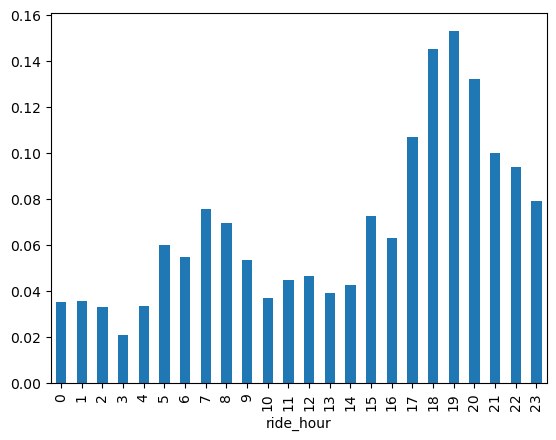

In [31]:
ride_hour_cancel = your_cab.groupby(
    'ride_hour'
)['Car_Cancellation'].mean()

ride_hour_cancel.plot(kind='bar')
plt.show()

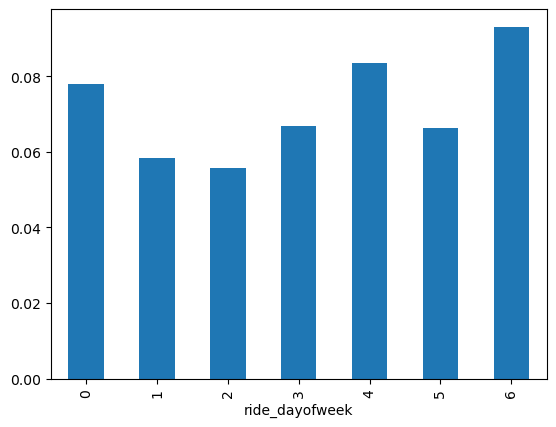

In [32]:
day_cancel = your_cab.groupby(
    'ride_dayofweek'
)['Car_Cancellation'].mean()

day_cancel.plot(kind='bar')
plt.show()

In [33]:
your_cab['customer_booking_count'].describe()

count    43389.000000
mean        19.236742
std         60.501115
min          1.000000
25%          1.000000
50%          2.000000
75%          7.000000
max        471.000000
Name: customer_booking_count, dtype: float64

In [34]:
your_cab.groupby(
    pd.qcut(
        your_cab['customer_booking_count'],
        q=4,
        duplicates='drop'
    ),
    observed=False
)['Car_Cancellation'].mean()

customer_booking_count
(0.999, 2.0]    0.090099
(2.0, 7.0]      0.054904
(7.0, 471.0]    0.051417
Name: Car_Cancellation, dtype: float64

In [35]:
your_cab = your_cab.drop(['id', 'user_id'], axis=1)

In [36]:
for col in [
    'booking_nature',
    'vehicle_model_id',
    'travel_type_id',
    'package_id'
]:
    print(col)
    print(your_cab[col].nunique())
    print()

booking_nature
4

vehicle_model_id
27

travel_type_id
3

package_id
8



In [37]:
from sklearn.preprocessing import LabelEncoder

le_booking = LabelEncoder()

your_cab['booking_nature'] = le_booking.fit_transform(
    your_cab['booking_nature']
)

In [38]:
your_cab['vehicle_model_id'].value_counts(normalize=True)*100

vehicle_model_id
12    73.371131
85     5.535965
89     5.510613
65     4.402037
28     3.911130
24     3.438660
87     1.299869
90     0.716772
23     0.679896
86     0.283482
10     0.239692
64     0.195902
54     0.168245
17     0.092189
91     0.057618
30     0.032266
36     0.020743
13     0.016133
72     0.004609
1      0.004609
43     0.004609
14     0.002305
69     0.002305
76     0.002305
75     0.002305
70     0.002305
39     0.002305
Name: proportion, dtype: float64

In [39]:
your_cab.describe(include='all')

,vehicle_model_id,package_id,travel_type_id,from_area_id,to_area_id,from_date,to_date,online_booking,mobile_site_booking,booking_created,...,Car_Cancellation,Cost_of_error,customer_booking_count,ride_hour,ride_dayofweek,booking_hour,booking_dayofweek,booking_advance_hours,is_same_day_booking,booking_nature
count,43389.000000,43389.000000,43389.000000,43389.000000,43389.000000,43389,25531,43389.000000,43389.000000,43389,...,43389.000000,43389.000000,43389.000000,43389.000000,43389.000000,43389.000000,43389.000000,43389.000000,43389.000000,43389.000000
mean,25.713222,0.352785,2.137132,713.763212,528.730554,2013-06-30 18:27:56.685335296,1970-01-01 00:00:00.000041507,0.351886,0.043283,2013-06-29 08:29:21.436769792,...,0.072161,8.007299,19.236742,12.024914,3.110328,14.368665,3.126599,33.976458,0.467330,1.231257
min,1.000000,0.000000,1.000000,2.000000,0.000000,2013-01-01 02:00:00,1970-01-01 00:00:00.000025569,0.000000,0.000000,2013-01-01 01:39:00,...,0.000000,0.150000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,0.000000,2.000000,393.000000,136.000000,2013-04-24 05:30:00,1970-01-01 00:00:00.000041480,0.000000,0.000000,2013-04-23 10:21:00,...,0.000000,1.000000,1.000000,7.000000,1.000000,11.000000,1.000000,2.900000,0.000000,1.000000
50%,12.000000,0.000000,2.000000,590.000000,393.000000,2013-07-10 08:15:00,1970-01-01 00:00:00.000041517,0.000000,0.000000,2013-07-07 22:28:00,...,0.000000,1.000000,2.000000,11.000000,3.000000,15.000000,3.000000,8.750000,0.000000,1.000000
75%,24.000000,0.000000,2.000000,1089.000000,977.000000,2013-09-11 23:00:00,1970-01-01 00:00:00.000041558,1.000000,0.000000,2013-09-09 21:22:00,...,0.000000,1.000000,7.000000,17.000000,5.000000,19.000000,5.000000,18.333333,1.000000,2.000000
max,91.000000,7.000000,3.000000,1403.000000,1403.000000,2014-02-08 05:45:00,1970-01-01 00:00:00.000041678,1.000000,1.000000,2013-11-24 14:50:00,...,1.000000,100.000000,471.000000,23.000000,6.000000,23.000000,6.000000,1906.900000,1.000000,3.000000
std,26.796983,0.981681,0.437535,419.639790,448.507911,NaN,NaN,0.477564,0.203495,NaN,...,0.258758,25.362025,60.501115,6.087864,1.987137,5.376008,1.953983,94.274862,0.498937,0.826348


In [40]:
print(your_cab.shape)

print(
    your_cab.isnull().sum().sum()
)

(43389, 24)
36110


In [41]:
your_cab['is_VMID_12'] = (
    your_cab['vehicle_model_id'] == 12
).astype(int)

In [42]:
your_cab = your_cab.drop('vehicle_model_id', axis=1)

In [43]:
your_cab.columns

Index(['package_id', 'travel_type_id', 'from_area_id', 'to_area_id',
       'from_date', 'to_date', 'online_booking', 'mobile_site_booking',
       'booking_created', 'from_lat', 'from_long', 'to_lat', 'to_long',
       'Car_Cancellation', 'Cost_of_error', 'customer_booking_count',
       'ride_hour', 'ride_dayofweek', 'booking_hour', 'booking_dayofweek',
       'booking_advance_hours', 'is_same_day_booking', 'booking_nature',
       'is_VMID_12'],
      dtype='object')

In [44]:
your_cab = your_cab.drop(
    ['from_date', 'to_date', 'booking_created'],
    axis=1
)

In [45]:
your_cab = your_cab.drop('Cost_of_error', axis=1)

In [46]:
your_cab = your_cab.drop(
    ['from_lat','from_long','to_lat','to_long'],
    axis=1
)

In [47]:
from imblearn.over_sampling import SMOTE

In [48]:
X = your_cab.drop('Car_Cancellation', axis=1)
y = your_cab['Car_Cancellation']

In [49]:
print(X)

       package_id  travel_type_id  from_area_id  to_area_id  online_booking  \
0             0.0               2          83.0       448.0               0   
1             0.0               2        1010.0       540.0               0   
2             0.0               2        1301.0      1034.0               0   
3             0.0               2         768.0       398.0               0   
4             0.0               2        1365.0       849.0               0   
...           ...             ...           ...         ...             ...   
43426         0.0               2        1147.0       452.0               1   
43427         0.0               2         393.0       466.0               1   
43428         1.0               3         974.0         0.0               0   
43429         0.0               2        1263.0       542.0               0   
43430         0.0               2         689.0       393.0               0   

       mobile_site_booking  customer_booking_count 

In [50]:
your_cab.isnull().sum()

package_id                0
travel_type_id            0
from_area_id              0
to_area_id                0
online_booking            0
mobile_site_booking       0
Car_Cancellation          0
customer_booking_count    0
ride_hour                 0
ride_dayofweek            0
booking_hour              0
booking_dayofweek         0
booking_advance_hours     0
is_same_day_booking       0
booking_nature            0
is_VMID_12                0
dtype: int64

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [52]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [53]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

Car_Cancellation
0    32206
1     2505
Name: count, dtype: int64
Car_Cancellation
0    32206
1    32206
Name: count, dtype: int64


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
feature_columns = X.columns.tolist()

In [56]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [57]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

In [58]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      8052
           1       0.33      0.45      0.38       626

    accuracy                           0.89      8678
   macro avg       0.64      0.69      0.66      8678
weighted avg       0.91      0.89      0.90      8678

[[7471  581]
 [ 346  280]]
ROC AUC: 0.818035802427988
